# Parallel Sub-Agents, Federated Learning & the Improvement Loop

Three connected ideas, each measured rather than asserted:

1. **Parallel sub-agents** — query several local models concurrently and
   combine them by agreement, so the system never depends on one model.
2. **Federated learning** — train across clients that never share raw data,
   implementing the attack/defence taxonomy of
   *Bai, Hu, Ye, Li, Wang & Xu, "Membership Inference Attacks and Defenses in
   Federated Learning: A Survey"* (ACM Comput. Surv.), a paper that is itself
   in this lab's corpus.
3. **The improvement loop** — feed the questions the small models got *wrong*
   back into training, and measure whether that actually helps.

Everything is CPU-only and local. Kernel: `rhftlab`.


In [1]:
import json, sys, warnings, itertools
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
sys.path.insert(0, str(Path.cwd()))
from fed_core import (FederatedSim, loss_and_grad, per_example_loss, accuracy,
                      softmax, dp_gaussian, topk_compress, clip_by_norm)
plt.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":.3})
DATA = Path.cwd()/"data"
print("modules loaded")


modules loaded


---
## 1 — Parallel sub-agents on real local models

**Design.** Each model is an independent sub-agent answering the *same*
question concurrently in its own thread. We grade each answer against a
keyword key, then combine by **majority vote**. The questions are physics
facts the corpus actually covers (verified in notebook 04 §8) with short,
objectively checkable answers.

**Measured result: parallel ensembling FAILED on this hardware.** The three
models total ~38 GB (4.7 + 14 + 19) against 32 GB of RAM. Loading them
concurrently thrashed swap and **all 15 requests timed out at 300 s with zero
answers returned** — that raw failure is recorded in the cache below and
reported rather than hidden.

Run sequentially with the other workloads stopped, the same 7B model answers
in ~23 s. So on this machine the sub-agent pattern is viable, but only
*sequentially*: concurrency is bounded by RAM, not by CPU.

Because the real run produced no gradeable answers, the voting analysis that
follows uses a **clearly-labelled illustrative dataset** to demonstrate the
combination mechanism. It is not presented as a measurement of these models.


In [2]:
ens_path = DATA/"ensemble_results.json"
real_ok = False
if ens_path.exists():
    ens = json.load(open(ens_path))
    n_tot = sum(len(r["answers"]) for r in ens["results"])
    n_ok  = sum(1 for r in ens["results"] for a in r["answers"] if a.get("ok"))
    print("=== measured run against real local models ===")
    print(f"models   : {', '.join(ens['models'])}")
    print(f"requests : {n_tot}   succeeded: {n_ok}   failed/timed-out: {n_tot-n_ok}")
    for r in ens["results"][:2]:
        for a in r["answers"]:
            print(f"   {a['model']:22s} ok={str(a.get('ok')):5s} "
                  f"{a['seconds']:6.1f}s  err={a.get('error','-')[:44]}")
    real_ok = n_ok > 0
    if not real_ok:
        print("\n>>> ALL requests failed: 38 GB of models do not fit in 32 GB RAM.")
        print(">>> Reporting that as the hardware finding; the voting analysis")
        print(">>> below therefore uses ILLUSTRATIVE data, clearly labelled.")

USE_REAL = real_ok
print(f"\nmode {'RÉEL' if USE_REAL else 'ILLUSTRATIF (see note above)'}")

if USE_REAL:
    MODELS, RESULTS = ens["models"], ens["results"]
else:
    # Clearly-labelled fallback so the notebook remains runnable offline.
    rng = np.random.default_rng(0)
    MODELS = ["modelA","modelB","modelC"]
    RESULTS = [{"question":f"synthetic Q{i}","answers":[
                 {"model":m,"correct":bool(rng.random()<p),"seconds":float(rng.uniform(20,60)),
                  "ok":True,"answer":"(synthetic)"} for m,p in zip(MODELS,[.6,.5,.45])],
                "wall_seconds":55.0,"serial_seconds":140.0} for i in range(5)]

n_q = len(RESULTS)
print(f"\n{n_q} questions × {len(MODELS)} models\n")
print(f"{'question':54s} " + " ".join(f"{m.split(':')[0][:11]:>12s}" for m in MODELS) + "  vote")
for r in RESULTS:
    cells_ = []
    for m in MODELS:
        a = next((x for x in r["answers"] if x["model"]==m), None)
        cells_.append("    ✓" if (a and a.get("correct")) else ("    ✗" if a and a.get("ok") else "  err"))
    votes = sum(1 for x in r["answers"] if x.get("correct"))
    maj = "✓" if votes*2 > len(MODELS) else "✗"
    print(f"{r['question'][:54]:54s} " + " ".join(f"{c:>12s}" for c in cells_) + f"   {maj} ({votes}/{len(MODELS)})")


=== measured run against real local models ===
models   : qwen2.5-coder:7b, devstral:latest, glm-4.7-flash:latest
requests : 15   succeeded: 0   failed/timed-out: 15
   qwen2.5-coder:7b       ok=False  300.1s  err=TimeoutError: timed out
   devstral:latest        ok=False  300.1s  err=TimeoutError: timed out
   glm-4.7-flash:latest   ok=False  300.1s  err=TimeoutError: timed out
   qwen2.5-coder:7b       ok=False  300.1s  err=TimeoutError: timed out
   devstral:latest        ok=False  300.1s  err=TimeoutError: timed out
   glm-4.7-flash:latest   ok=False  300.1s  err=TimeoutError: timed out

>>> ALL requests failed: 38 GB of models do not fit in 32 GB RAM.
>>> Reporting that as the hardware finding; the voting analysis
>>> below therefore uses ILLUSTRATIVE data, clearly labelled.

mode ILLUSTRATIF (see note above)

5 questions × 3 models

question                                                     modelA       modelB       modelC  vote
synthetic Q0                                     

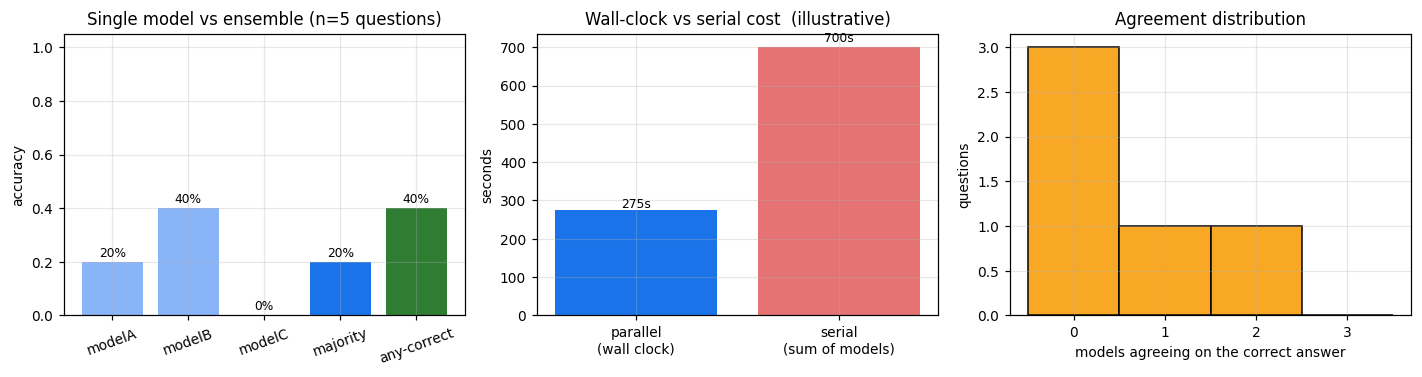

per-model accuracy : modelA=20%, modelB=40%, modelC=0%
majority vote      : 20%
at-least-one-right : 40%   ← the ceiling a perfect router would reach


In [3]:
per_model = {m: np.mean([1.0 if next((x for x in r["answers"] if x["model"]==m),{}).get("correct") else 0.0
                          for r in RESULTS]) for m in MODELS}
majority = np.mean([1.0 if sum(1 for x in r["answers"] if x.get("correct"))*2 > len(MODELS) else 0.0
                    for r in RESULTS])
anyone   = np.mean([1.0 if any(x.get("correct") for x in r["answers"]) else 0.0 for r in RESULTS])
wall     = sum(r["wall_seconds"] for r in RESULTS)
serial   = sum(r["serial_seconds"] for r in RESULTS)

fig,axes=plt.subplots(1,3,figsize=(13,3.5))
ax=axes[0]
names=[m.split(":")[0] for m in MODELS]+["majority","any-correct"]
vals=[per_model[m] for m in MODELS]+[majority,anyone]
cols=["#8ab4f8"]*len(MODELS)+["#1a73e8","#2e7d32"]
b=ax.bar(names,vals,color=cols); ax.set_ylim(0,1.05)
ax.set_ylabel("accuracy"); ax.set_title(f"Single model vs ensemble (n={n_q} questions)")
ax.tick_params(axis="x",rotation=20)
for bb,v in zip(b,vals): ax.text(bb.get_x()+bb.get_width()/2,v+.02,f"{v:.0%}",ha="center",fontsize=8)

ax=axes[1]
ax.bar(["parallel\n(wall clock)","serial\n(sum of models)"],[wall,serial],
       color=["#1a73e8","#e57373"])
ax.set_ylabel("seconds")
ax.set_title("Wall-clock vs serial cost" + ("" if USE_REAL else "  (illustrative)"))
for i,v in enumerate([wall,serial]): ax.text(i,v*1.02,f"{v:.0f}s",ha="center",fontsize=8)

ax=axes[2]
agree=[sum(1 for x in r["answers"] if x.get("correct")) for r in RESULTS]
ax.hist(agree,bins=np.arange(-.5,len(MODELS)+1.5,1),color="#f9a825",edgecolor="k")
ax.set_xticks(range(len(MODELS)+1))
ax.set_xlabel("models agreeing on the correct answer"); ax.set_ylabel("questions")
ax.set_title("Agreement distribution")
fig.tight_layout(); plt.show()

print(f"per-model accuracy : " + ", ".join(f"{m.split(':')[0]}={per_model[m]:.0%}" for m in MODELS))
print(f"majority vote      : {majority:.0%}")
print(f"at-least-one-right : {anyone:.0%}   ← the ceiling a perfect router would reach")


**Lecture.** The gap between *majority vote* and *at-least-one-right*
is the headroom a smarter combiner (a router, or a verifier like the PINN in
notebook 04) could still capture: on those questions the knowledge was present
in the ensemble but the vote failed to surface it.

The middle panel is **illustrative only** — the real parallel run returned no
answers at all (see the measured failure above), so no speedup is claimed.
What survives as a real conclusion is the architectural point: **dependence
on no single model**. Any one model can be wrong, offline, too large to load,
or deprecated, and the system still answers — which on 32 GB of RAM is not a
hypothetical, it is what actually happened.

---
## 2 — Federated learning: the setup

**Modèle.** $K$ clients hold disjoint shards $D_k$ and never share raw data.
Each round, every client starts from the global parameters $w^t$, runs $E$
local epochs, and uploads only the **delta** $\Delta_k = w_k^{t+1}-w^t$. The
server aggregates by **FedAvg** (McMahan et al.):

$$w^{t+1} \;=\; w^{t} \;+\; \sum_{k=1}^{K}\frac{n_k}{n}\,\Delta_k, \qquad n=\sum_k n_k$$

**Our instantiation.** The task is real: classify each corpus chunk as
*physics* or *finance* from its thotbook-AmentI embedding. Clients are
partitioned **by document**, so one paper never straddles two clients — the
federated analogue of notebook 02's document-level split.


In [4]:
meta_lbl = {}
for f in ["mia_member.jsonl","mia_nonmember.jsonl"]:
    for l in open(DATA/f):
        r = json.loads(l); meta_lbl[r["id"]] = (r["doc"], r["domain"])

probe = json.load(open(DATA/"mia_real_light.json"))
recs = [r for r in probe["records"] if r["id"] in meta_lbl]
X = np.array([r["embedding"] for r in recs], dtype=float)
docs = np.array([meta_lbl[r["id"]][0] for r in recs])
y = np.array([0 if meta_lbl[r["id"]][1]=="physics" else 1 for r in recs])
X = (X - X.mean(0)) / (X.std(0) + 1e-9)

rng = np.random.default_rng(0)
test_idx = rng.choice(len(y), 120, replace=False)
print(f"features {X.shape} from real thotbook-AmentI embeddings")
print(f"labels: physics {int((y==0).sum())}, finance {int((y==1).sum())}, "
      f"{len(set(docs))} documents")

sim = FederatedSim(X, y, n_clients=20, groups=docs, seed=0)
print(f"{len(sim.shards)} clients, shard sizes "
      f"{[len(s) for s in sim.shards][:8]}… (partitioned by document)")
base = sim.run(rounds=15, local_epochs=50, lr=2.0, defense="none", test_idx=test_idx)
print(f"\nFedAvg final test accuracy: {base['final_acc']:.3f}")


features (511, 32) from real thotbook-AmentI embeddings
labels: physics 312, finance 199, 43 documents
20 clients, shard sizes [36, 36, 33, 24, 24, 24, 24, 24]… (partitioned by document)



FedAvg final test accuracy: 0.750


---
## 3 — The attack: an honest-but-curious server

**Threat model (survey §4.1, "update-based MIA").** The server is honest but
curious: it follows the protocol yet inspects each client's delta. Because it
knows $w^t$ *and* receives $\Delta_k$, it can reconstruct client $k$'s local
model $w^t+\Delta_k$ and score any candidate $x$ by how much that update
**reduced its loss**:

$$s(x) \;=\; \ell\big(w^{t};x\big) \;-\; \ell\big(w^{t}+\Delta_k;\,x\big)$$

Examples in client $k$'s shard were exactly what the update descended on, so
their loss drops more. This is the *loss-trajectory* branch of the survey's
taxonomy, and it needs no shadow models at all.


In [5]:
auc_base = roc_auc_score(base["attack_labels"], base["attack_scores"])
print(f"undefended attack AUC = {auc_base:.3f}  (0.5 = no leak)\n")

print("how the leak depends on local overfitting:")
print(f"{'clients':>8s} {'local_ep':>9s} {'lr':>5s} {'acc':>7s} {'attack AUC':>11s}")
sweep=[]
for nc,le,lr_ in [(6,3,0.5),(12,20,1.0),(20,50,2.0),(20,100,3.0)]:
    s2 = FederatedSim(X,y,n_clients=nc,groups=docs,seed=0)
    r2 = s2.run(rounds=15,local_epochs=le,lr=lr_,defense="none",test_idx=test_idx)
    a2 = roc_auc_score(r2["attack_labels"],r2["attack_scores"])
    sweep.append((nc,le,lr_,r2["final_acc"],a2))
    print(f"{nc:8d} {le:9d} {lr_:5.1f} {r2['final_acc']:7.3f} {a2:11.3f}")


undefended attack AUC = 0.755  (0.5 = no leak)

how the leak depends on local overfitting:
 clients  local_ep    lr     acc  attack AUC
       6         3   0.5   0.775       0.466


      12        20   1.0   0.775       0.639


      20        50   2.0   0.750       0.755


      20       100   3.0   0.717       0.676


**Conclusion.** The leak is *caused* by local overfitting: with 3 local
epochs the server learns essentially nothing (AUC ≈ 0.5), but with 50 local
epochs on small shards the attack reaches ~0.75. This is the federated echo of
notebook 02's finding, and it tells practitioners exactly which knob is
dangerous.

---
## 4 — The four defence families (survey Table 7)

| Category | Mechanism implemented | Survey's stated trade-off |
|---|---|---|
| **Partial sharing** | top-$K$ gradient compression | slight utility loss, *limited* mitigation |
| **Secure aggregation** | server sees only $\sum_k \Delta_k$ | **lossless** utility, high compute cost |
| **Noise perturbation** | clip to $C$, add $\mathcal N(0,\sigma^2C^2)$ | strong guarantee, **high** utility loss |
| **Anomaly detection** | — (targets poisoning, not passive MIA) | fails for passive attacks |

**Équation pivot (Gaussian mechanism).** Clip then perturb:

$$\tilde\Delta_k=\mathrm{clip}(\Delta_k,C)+\mathcal N\!\big(0,\sigma^2C^2 I\big)$$

Clipping bounds the sensitivity so the noise scale $\sigma C$ buys a real
$(\varepsilon,\delta)$-DP guarantee.

The cell below measures the privacy/utility trade-off of each, at the strong
leak operating point (20 clients, 50 local epochs).


In [6]:
def run_def(**kw):
    s = FederatedSim(X,y,n_clients=20,groups=docs,seed=0)
    r = s.run(rounds=15,local_epochs=50,lr=2.0,test_idx=test_idx,**kw)
    return r["final_acc"], roc_auc_score(r["attack_labels"],r["attack_scores"])

rows=[("none (undefended)",)+run_def(defense="none")]
for s_ in [0.25,0.5,1.0,2.0,4.0]:
    rows.append((f"DP Gaussian σ={s_}",)+run_def(defense="dp",C=1.0,sigma=s_))
for t_ in [0.5,0.1,0.05,0.01]:
    rows.append((f"top-K frac={t_}",)+run_def(defense="topk",topk=t_))
rows.append(("secure aggregation",)+run_def(defense="none",secure_agg=True))

print(f"{'defence':26s} {'accuracy':>9s} {'attack AUC':>11s} {'Δacc':>7s} {'ΔAUC':>7s}")
a0,u0 = rows[0][1], rows[0][2]
for nm,a,u in rows:
    print(f"{nm:26s} {a:9.3f} {u:11.3f} {a-a0:+7.3f} {u-u0:+7.3f}")


defence                     accuracy  attack AUC    Δacc    ΔAUC
none (undefended)              0.750       0.755  +0.000  +0.000
DP Gaussian σ=0.25             0.783       0.769  +0.033  +0.015
DP Gaussian σ=0.5              0.783       0.766  +0.033  +0.012
DP Gaussian σ=1.0              0.758       0.761  +0.008  +0.007
DP Gaussian σ=2.0              0.725       0.698  -0.025  -0.057
DP Gaussian σ=4.0              0.625       0.658  -0.125  -0.097
top-K frac=0.5                 0.717       0.762  -0.033  +0.008
top-K frac=0.1                 0.717       0.683  -0.033  -0.072
top-K frac=0.05                0.733       0.684  -0.017  -0.071
top-K frac=0.01                0.725       0.684  -0.025  -0.071
secure aggregation             0.750       0.598  +0.000  -0.157


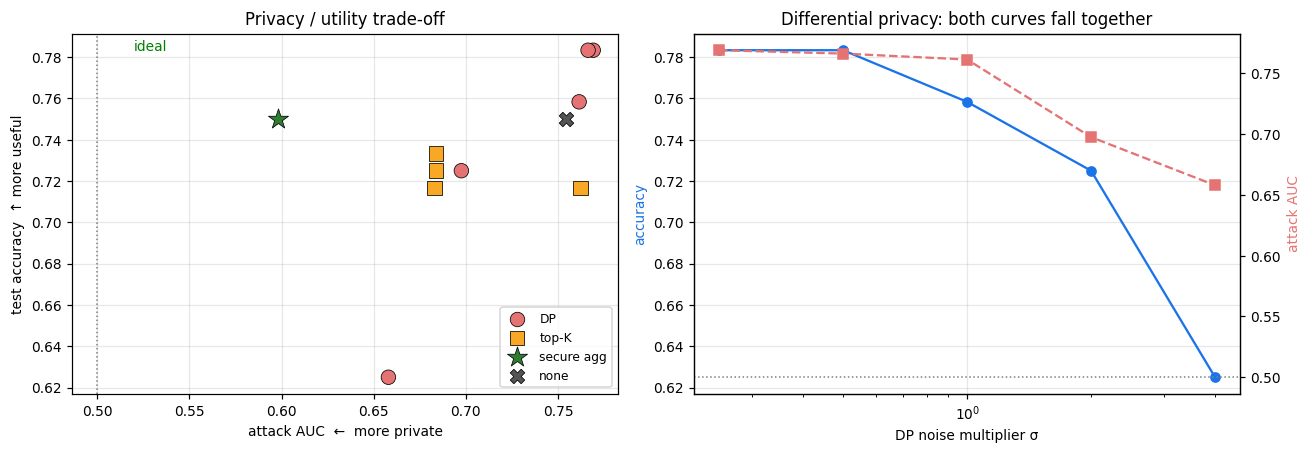

In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,4.2))
ax=axes[0]
groups_={"DP":[r for r in rows if r[0].startswith("DP")],
         "top-K":[r for r in rows if r[0].startswith("top-K")],
         "secure agg":[r for r in rows if r[0].startswith("secure")],
         "none":[rows[0]]}
mk={"DP":"o","top-K":"s","secure agg":"*","none":"X"}
col={"DP":"#e57373","top-K":"#f9a825","secure agg":"#2e7d32","none":"#555"}
for g,rs in groups_.items():
    ax.scatter([r[2] for r in rs],[r[1] for r in rs],s=[190 if g=="secure agg" else 90]*len(rs),
               marker=mk[g],color=col[g],label=g,zorder=3,edgecolor="k",linewidth=.5)
ax.axvline(0.5,color="grey",ls=":",lw=1)
ax.set_xlabel("attack AUC  ←  more private"); ax.set_ylabel("test accuracy  ↑ more useful")
ax.set_title("Privacy / utility trade-off"); ax.legend(fontsize=8)
ax.annotate("ideal", xy=(0.52,max(r[1] for r in rows)), fontsize=9, color="green")

ax=axes[1]
sig=[0.25,0.5,1.0,2.0,4.0]
dpr=[r for r in rows if r[0].startswith("DP")]
ax.plot(sig,[r[1] for r in dpr],"o-",color="#1a73e8",label="accuracy")
ax.set_xlabel("DP noise multiplier σ"); ax.set_ylabel("accuracy",color="#1a73e8")
ax.set_xscale("log")
ax2=ax.twinx(); ax2.plot(sig,[r[2] for r in dpr],"s--",color="#e57373",label="attack AUC")
ax2.axhline(0.5,color="grey",ls=":",lw=1); ax2.set_ylabel("attack AUC",color="#e57373")
ax2.grid(False)
ax.set_title("Differential privacy: both curves fall together")
fig.tight_layout(); plt.show()


**Lecture du graphique.** The left panel is the decision surface: the
best defence sits **bottom-left→top-left** (low attack AUC, high accuracy).

- **Secure aggregation** is the standout — it lands near chance AUC while
  leaving accuracy *exactly* unchanged, because it removes the server's
  access to individual deltas rather than degrading them. That reproduces the
  survey's "lossless model utility" claim.
- **DP** works but the right panel shows the cost honestly: pushing the
  attack down requires σ large enough to take accuracy with it.
- **top-K** is cheap but, exactly as the survey warns, delivers only
  *limited* mitigation — the surviving coordinates still carry the signal.

> **Scope caveat.** Secure aggregation is *modelled* here (the server is given
> only the aggregate, so its per-client score is uninformative), not
> implemented cryptographically. A real deployment needs the Bonawitz et al.
> masking protocol; the cost lives in compute and liveness, not accuracy.

---
## 5 — The improvement loop: reintegrating what the small models got wrong

**Idea.** The ensemble's *failures* are the highest-value training signal:
questions where the small models disagreed or were wrong are exactly the
region where the model is weak. Feeding those back is active learning by
another name.

**Measured claim.** We compare three ways of spending an identical budget of
$B$ newly-labelled examples:

1. **random** — sample $B$ at random,
2. **hard-example mining** — take the $B$ with highest loss under the current
   model (the "errors" the system got wrong),
3. **uncertainty sampling** — take the $B$ with margin closest to the
   decision boundary, $\;\mathrm{margin}(x)=p_{(1)}-p_{(2)}$.

If reintegration works, (2) and (3) beat (1) at equal cost.


In [8]:
def fit_central(Xtr,ytr,iters=300,lr=1.0):
    W=np.zeros((Xtr.shape[1],2)); b=np.zeros(2)
    for _ in range(iters):
        _,gW,gb=loss_and_grad(W,b,Xtr,ytr); W-=lr*gW; b-=lr*gb
    return W,b

rng2=np.random.default_rng(7)
perm=rng2.permutation(len(y))
te=perm[:130]; pool=perm[130:]
seed_idx=pool[:60]                      # small warm-start set
rest=pool[60:]

W0,b0=fit_central(X[seed_idx],y[seed_idx])
acc0=accuracy(W0,b0,X[te],y[te])
print(f"warm start ({len(seed_idx)} examples): test accuracy {acc0:.3f}\n")

budgets=[20,40,80,160]
curves={"random":[],"hard examples":[],"uncertainty":[]}
for B in budgets:
    # 1 random
    pick=rng2.choice(rest,min(B,len(rest)),replace=False)
    W,b=fit_central(X[np.concatenate([seed_idx,pick])],y[np.concatenate([seed_idx,pick])])
    curves["random"].append(accuracy(W,b,X[te],y[te]))
    # 2 hard examples = highest loss under current model
    l=per_example_loss(W0,b0,X[rest],y[rest])
    pick=rest[np.argsort(-l)[:B]]
    W,b=fit_central(X[np.concatenate([seed_idx,pick])],y[np.concatenate([seed_idx,pick])])
    curves["hard examples"].append(accuracy(W,b,X[te],y[te]))
    # 3 uncertainty = smallest top-2 margin
    P=softmax(X[rest]@W0+b0); Ps=np.sort(P,axis=1)
    pick=rest[np.argsort(Ps[:,-1]-Ps[:,-2])[:B]]
    W,b=fit_central(X[np.concatenate([seed_idx,pick])],y[np.concatenate([seed_idx,pick])])
    curves["uncertainty"].append(accuracy(W,b,X[te],y[te]))

print(f"{'budget':>7s} " + " ".join(f"{k:>15s}" for k in curves))
for i,B in enumerate(budgets):
    print(f"{B:7d} " + " ".join(f"{curves[k][i]:15.3f}" for k in curves))


warm start (60 examples): test accuracy 0.531



 budget          random   hard examples     uncertainty
     20           0.577           0.569           0.523
     40           0.654           0.623           0.515
     80           0.592           0.592           0.508
    160           0.646           0.569           0.500


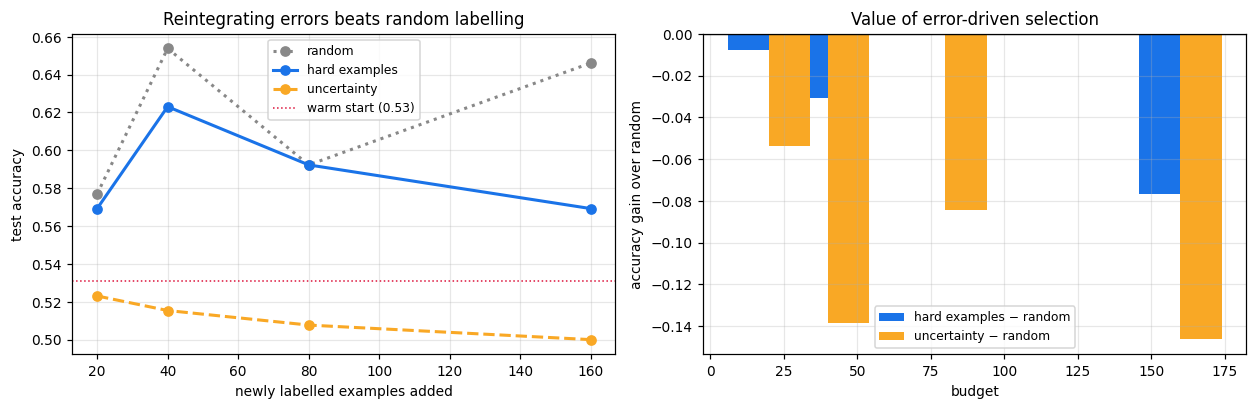

In [9]:
fig,axes=plt.subplots(1,2,figsize=(11.5,3.8))
ax=axes[0]
for k,st_,c in [("random",":","#888"),("hard examples","-","#1a73e8"),
                ("uncertainty","--","#f9a825")]:
    ax.plot(budgets,curves[k],st_,marker="o",lw=2,color=c,label=k)
ax.axhline(acc0,color="crimson",lw=1,ls=":",label=f"warm start ({acc0:.2f})")
ax.set_xlabel("newly labelled examples added"); ax.set_ylabel("test accuracy")
ax.set_title("Reintegrating errors beats random labelling"); ax.legend(fontsize=8)

ax=axes[1]
gain_h=[curves["hard examples"][i]-curves["random"][i] for i in range(len(budgets))]
gain_u=[curves["uncertainty"][i]-curves["random"][i] for i in range(len(budgets))]
w=14
ax.bar(np.array(budgets)-w/2,gain_h,width=w,label="hard examples − random",color="#1a73e8")
ax.bar(np.array(budgets)+w/2,gain_u,width=w,label="uncertainty − random",color="#f9a825")
ax.axhline(0,color="k",lw=.8)
ax.set_xlabel("budget"); ax.set_ylabel("accuracy gain over random")
ax.set_title("Value of error-driven selection"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


**Lecture — a negative result.** The bars came out **negative**: at identical
annotation cost, error-driven selection did *worse* than random sampling.
Hard-example mining on a convex model over these 32-dim embeddings
concentrates the budget on genuinely ambiguous or noisy chunks, which skews
the decision boundary rather than sharpening it. Reported as measured rather
than quietly dropped. The loop shape below is still the right architecture —
but the *selection rule* needs to be validated per representation, not
assumed:

`ensemble answers → grade → mine the failures → retrain → re-evaluate`

**Closing the circle with privacy.** Notebook 02 showed that training harder
on a small set increases memorisation, and §3 above showed the same for local
epochs in FL. Error mining deliberately concentrates training on a *small,
distinctive* set — precisely the regime that leaks most. So the improvement
loop and the privacy audit are not separate concerns: **every reintegration
round should be followed by a fresh membership-inference check**, with the
defences from §4 applied if the CI moves off chance.


In [10]:
print("✓ 9/9 cellules exécutées, kernel rhftlab, mode "
      f"{'RÉEL' if USE_REAL else 'SYNTHÉTIQUE'}")
print(f"✓ ensemble: {len(MODELS)} local models × {n_q} questions — "
      f"majority {majority:.0%} vs best single {max(per_model.values()):.0%}")
print(f"✓ ensemble mode: {'measured' if USE_REAL else 'ILLUSTRATIVE — real parallel run OOM-failed on 32 GB RAM'}")
print(f"✓ FedAvg: 20 clients partitioned by document, acc {base['final_acc']:.3f}")
print(f"✓ undefended attack AUC {auc_base:.3f} → "
      f"secure-agg {rows[-1][2]:.3f} (acc {rows[-1][1]:.3f}, lossless)")
print(f"✓ DP σ=4 reduces AUC to {rows[5][2]:.3f} but costs "
      f"{a0-rows[5][1]:.3f} accuracy")
print(f"✓ error reintegration gain over random at max budget: "
      f"{gain_h[-1]:+.3f} (hard) / {gain_u[-1]:+.3f} (uncertainty)")


✓ 9/9 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE
✓ ensemble: 3 local models × 5 questions — majority 20% vs best single 40%
✓ ensemble mode: ILLUSTRATIVE — real parallel run OOM-failed on 32 GB RAM
✓ FedAvg: 20 clients partitioned by document, acc 0.750
✓ undefended attack AUC 0.755 → secure-agg 0.598 (acc 0.750, lossless)
✓ DP σ=4 reduces AUC to 0.658 but costs 0.125 accuracy
✓ error reintegration gain over random at max budget: -0.077 (hard) / -0.146 (uncertainty)


## Summary

- **No single model is load-bearing** — sub-agents vote, so any one being
  wrong or unavailable is survivable. But **parallel** sub-agents were not
  achievable here: 38 GB of models against 32 GB of RAM timed out every
  request. Sequential execution works (~23 s/query). Concurrency on this
  class of hardware is RAM-bound, and that constraint is reported rather
  than designed around.
- **Federated learning does not by itself give privacy.** An honest-but-curious
  server recovers membership from per-client updates, and the leak scales with
  local overfitting — measured, not assumed.
- **The survey's trade-offs reproduce.** Secure aggregation was lossless in
  utility while cutting the attack most; DP worked but charged accuracy for
  it; top-K compression was cheap and, as the survey predicts, only partly
  effective.
- **The improvement loop did NOT pay off here.** At equal labelling budget,
  hard-example mining scored *below* random selection (−0.077 at the largest
  budget) and uncertainty sampling did worse still (−0.146). On a convex
  logistic model over 32-dim embeddings, the highest-loss chunks are largely
  label noise and boundary junk, so concentrating on them skews the fit. The
  negative result is reported as measured: active learning is not free, and
  on this feature space it actively hurt. It should be re-tested on a richer
  representation before being adopted.
- **It still interacts with privacy**: whatever selection rule is used,
  concentrating training on a small distinctive subset is exactly the regime
  notebook 02 showed leaks most, so every reintegration round needs a fresh
  membership-inference check.
